In [1]:
import numpy as np
import pandas as pd
import os, json
import matplotlib.pyplot as plt

# Table: Vanilla -> Attacked Vanilla -> Attacked EdgeAdder (Defense)

In [2]:
def agg_clean_and_attacked_results(df_vanilla:pd.DataFrame, df_edge_adder:pd.DataFrame, attack_mode:str):
    non_numerical_cols = ['dataset', 'encoder', 'model', 'attack_mode']

    # none
    df1 = df_vanilla[(df_vanilla["model"] == "vanilla") & (df_vanilla["attack_mode"] == "none")]
    df1 = df1.drop(columns=non_numerical_cols).add_suffix('_clean')

    # degree
    df2 = df_vanilla[(df_vanilla["model"] == "vanilla") & (df_vanilla["attack_mode"] == attack_mode)]
    df_indices = df2[non_numerical_cols]
    df2 = df2.drop(columns=non_numerical_cols).add_suffix('_attacked')

    # edge_adder
    df3 = df_edge_adder[(df_edge_adder["model"] == "edge_adder") & (df_edge_adder["attack_mode"] == attack_mode)]
    df3 = df3.drop(columns=non_numerical_cols).add_suffix('_defended')

    # concatenate
    df_table = pd.concat([
        df_indices.reset_index(drop=True),
        df1.reset_index(drop=True),
        df2.reset_index(drop=True),
        df3.reset_index(drop=True)
    ], axis=1)

    utility_cols = ["AUC_mean_clean", "AUC_mean_attacked", "AUC_mean_defended",
                    "F1_mean_clean", "F1_mean_attacked", "F1_mean_defended"]
    fairness_cols = ["DP_mean_clean", "DP_mean_attacked", "DP_mean_defended",
                    "EO_mean_clean", "EO_mean_attacked", "EO_mean_defended"]
    df_table_fairness_mean_only = df_table[non_numerical_cols + fairness_cols]

    return df_table, df_table_fairness_mean_only

In [32]:
def hist_attack_defense_effects(df, fairness_metric:str, attack_mode:str, defense: bool = True):
    attack_effect = df[f"{fairness_metric}_mean_attacked"] - df[f"{fairness_metric}_mean_clean"]
    plt.figure(figsize=(5, 3))
    plt.hist(attack_effect * 100, bins=20, alpha=0.5, label=f'Attack Effect ({fairness_metric} increase due to attack)')
    if defense:
        defense_effect = df[f"{fairness_metric}_mean_defended"] - df[f"{fairness_metric}_mean_attacked"]
        plt.hist(defense_effect * 100, bins=20, alpha=0.5, label=f'Defense Effect ({fairness_metric} change due to defense)')
    plt.xlabel(f'Change in {fairness_metric} (%)')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of NIFA {attack_mode.capitalize()} Attack and Defense Effects on {fairness_metric}', fontsize=10)
    plt.legend(fontsize=8)
    plt.show()

In [4]:
df_tables = {}

## Tuned vanilla + Default NIFA attack + Default EdgeAdder

In [5]:
attack_mode = "degree"
df_vanilla = pd.read_csv(f"./vanilla_rerun_before_and_after_nifa_{attack_mode}.csv")
df_edge_adder = pd.read_csv(f"./edge_adder_rerun_before_and_after_nifa_{attack_mode}.csv")
df_tables[attack_mode], _ = agg_clean_and_attacked_results(df_vanilla, df_edge_adder, attack_mode)

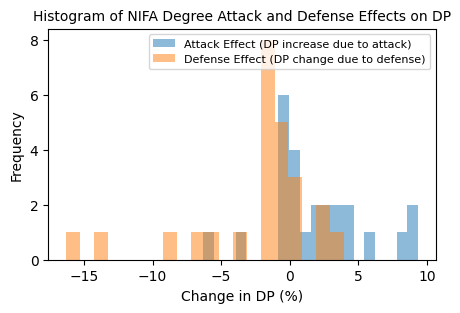

In [6]:
fairness_metric = "DP"
hist_attack_defense_effects(df_tables[attack_mode], fairness_metric, attack_mode)

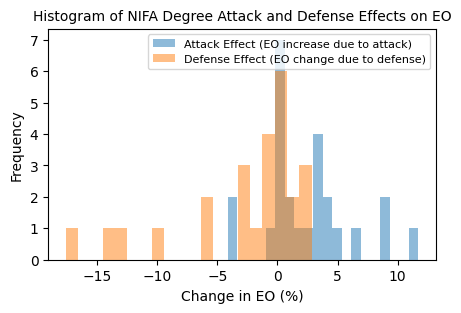

In [7]:
fairness_metric = "EO"
hist_attack_defense_effects(df_tables[attack_mode], fairness_metric, attack_mode)

### Vanilla clean -> NIFA (uncertainty) -> Attacked EdgeAdder

In [8]:
attack_mode = "uncertainty"
df_vanilla = pd.read_csv(f"./vanilla_rerun_before_and_after_nifa_{attack_mode}.csv")
df_edge_adder = pd.read_csv(f"./edge_adder_rerun_before_and_after_nifa_{attack_mode}.csv")
df_tables[attack_mode], _ = agg_clean_and_attacked_results(df_vanilla, df_edge_adder, attack_mode)

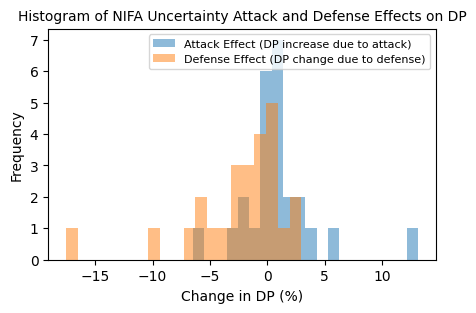

In [9]:
fairness_metric = "DP"
hist_attack_defense_effects(df_tables[attack_mode], fairness_metric, attack_mode)

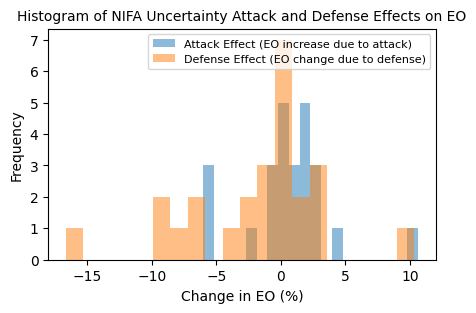

In [10]:
fairness_metric = "EO"
hist_attack_defense_effects(df_tables[attack_mode], fairness_metric, attack_mode)

### Concatenate two tables together

In [11]:
df_table = pd.concat([df_tables["degree"], df_tables["uncertainty"]], axis=0)
df_table.sort_values(by=['dataset', 'encoder'], inplace=True)
df_table.to_csv("./main_table_all_attacks.csv", index=False)

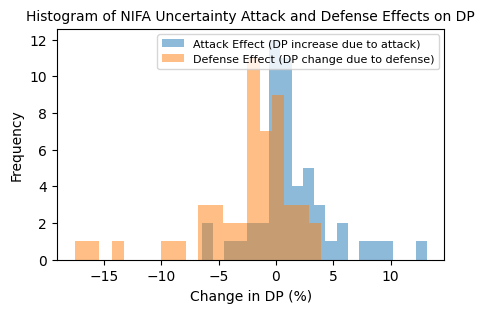

In [12]:
fairness_metric = "DP"
hist_attack_defense_effects(df_table, fairness_metric, attack_mode)

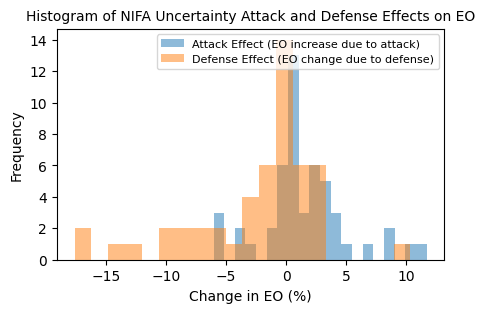

In [13]:
fairness_metric = "EO"
hist_attack_defense_effects(df_table, fairness_metric, attack_mode)

In [14]:
df_table_easy_compare_mean = df_table[
    ['dataset', 'encoder', "attack_mode",
     'AUC_mean_clean', 'AUC_mean_attacked', 'AUC_mean_defended',
     'F1_mean_clean', 'F1_mean_attacked', 'F1_mean_defended',
     'DP_mean_clean', 'DP_mean_attacked', 'DP_mean_defended',
     'EO_mean_clean', 'EO_mean_attacked', 'EO_mean_defended']
]

df_table_easy_compare_std = df_table[
    ['dataset', 'encoder', "attack_mode",
     'AUC_std_clean', 'AUC_std_attacked', 'AUC_std_defended',
     'F1_std_clean', 'F1_std_attacked', 'F1_std_defended',
     'DP_std_clean', 'DP_std_attacked', 'DP_std_defended',
     'EO_std_clean', 'EO_std_attacked', 'EO_std_defended']
]

In [15]:
df_table_easy_compare_mean.to_csv("./main_table_all_attacks_mean.csv", index=False)
df_table_easy_compare_std.to_csv("./main_table_all_attacks_std.csv", index=False)

## Tuned vanilla + Tuned NIFA attack + Tuned EdgeAdder

In [ ]:
attack_mode = "tuned_nifa"
df_vanilla = pd.read_csv(f"./vanilla_rerun_before_and_after_{attack_mode}.csv")
df_edge_adder = pd.read_csv(f"./edge_adder_rerun_before_and_after_{attack_mode}.csv")
df_tables[attack_mode], _ = agg_clean_and_attacked_results(df_vanilla, df_edge_adder, attack_mode)

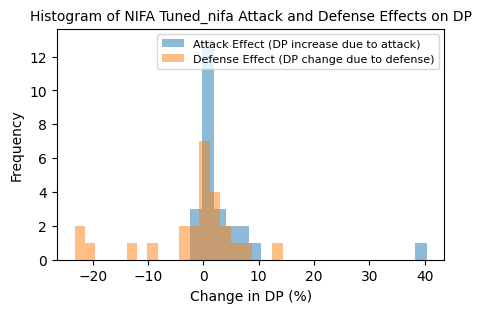

In [18]:
fairness_metric = "DP"
hist_attack_defense_effects(df_tables[attack_mode], fairness_metric, attack_mode)

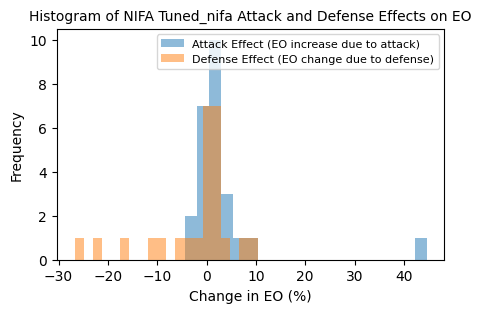

In [19]:
fairness_metric = "EO"
hist_attack_defense_effects(df_tables[attack_mode], fairness_metric, attack_mode)

In [24]:
df_table_easy_compare_mean = df_tables[attack_mode][
    ['dataset', 'encoder', "attack_mode",
     'AUC_mean_clean', 'AUC_mean_attacked', 'AUC_mean_defended',
     'F1_mean_clean', 'F1_mean_attacked', 'F1_mean_defended',
     'DP_mean_clean', 'DP_mean_attacked', 'DP_mean_defended',
     'EO_mean_clean', 'EO_mean_attacked', 'EO_mean_defended']
]

df_table_easy_compare_std = df_tables[attack_mode][
    ['dataset', 'encoder', "attack_mode",
     'AUC_std_clean', 'AUC_std_attacked', 'AUC_std_defended',
     'F1_std_clean', 'F1_std_attacked', 'F1_std_defended',
     'DP_std_clean', 'DP_std_attacked', 'DP_std_defended',
     'EO_std_clean', 'EO_std_attacked', 'EO_std_defended']
]

In [27]:
root = "./main_tables/tuned_vanilla_tuned_nifa"
df_tables[attack_mode].to_csv(f"{root}/main_table_all_attacks.csv", index=False)

In [28]:
df_table_easy_compare_mean.to_csv(f"{root}/main_table_all_attacks_mean.csv", index=False)
df_table_easy_compare_std.to_csv(f"{root}/main_table_all_attacks_std.csv", index=False)

## Tuned vanilla + Default NIFA attack + Default FairINV

In [38]:
df_tables = {}
model = "fairinv"

In [39]:
attack_mode = "degree"
df_vanilla = pd.read_csv(f"./vanilla_rerun_before_and_after_nifa_{attack_mode}.csv")
df_edge_adder = pd.read_csv(f"./{model}_rerun_before_and_after_nifa_{attack_mode}.csv")
df_tables[attack_mode], _ = agg_clean_and_attacked_results(df_vanilla, df_edge_adder, attack_mode)

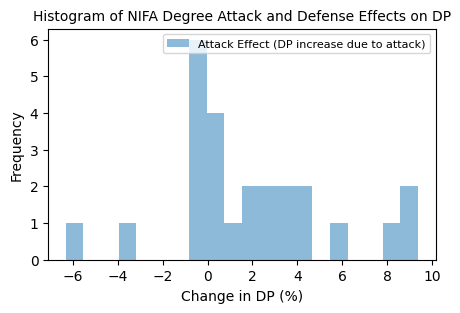

In [40]:
fairness_metric = "DP"
hist_attack_defense_effects(df_tables[attack_mode], fairness_metric, attack_mode, defense=False)

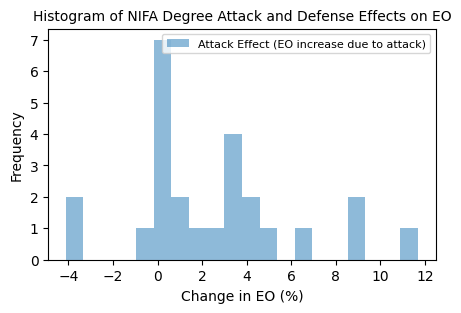

In [41]:
fairness_metric = "EO"
hist_attack_defense_effects(df_tables[attack_mode], fairness_metric, attack_mode, defense=False)

### Vanilla clean -> NIFA (uncertainty) -> Attacked EdgeAdder

In [42]:
attack_mode = "uncertainty"
df_vanilla = pd.read_csv(f"./vanilla_rerun_before_and_after_nifa_{attack_mode}.csv")
df_edge_adder = pd.read_csv(f"./{model}_rerun_before_and_after_nifa_{attack_mode}.csv")
df_tables[attack_mode], _ = agg_clean_and_attacked_results(df_vanilla, df_edge_adder, attack_mode)

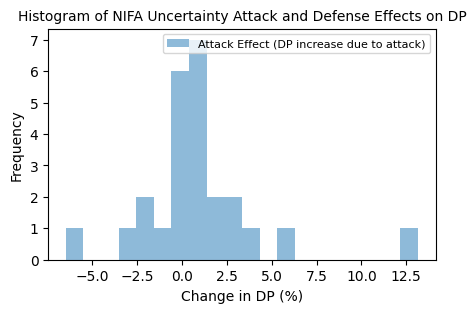

In [45]:
fairness_metric = "DP"
hist_attack_defense_effects(df_tables[attack_mode], fairness_metric, attack_mode, defense=False)

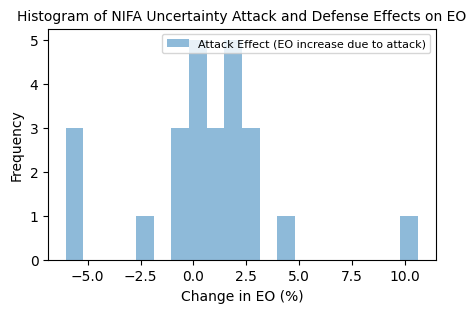

In [46]:
fairness_metric = "EO"
hist_attack_defense_effects(df_tables[attack_mode], fairness_metric, attack_mode, defense=False)

### Concatenate two tables together

In [47]:
df_table = pd.concat([df_tables["degree"], df_tables["uncertainty"]], axis=0)
df_table.sort_values(by=['dataset', 'encoder'], inplace=True)
df_table.to_csv("./main_tables/tuned_fairinv_default_nifa/main_table_all_attacks.csv", index=False)

In [48]:
df_table_easy_compare_mean = df_table[
    ['dataset', 'encoder', "attack_mode",
     'AUC_mean_clean', 'AUC_mean_attacked', 'AUC_mean_defended',
     'F1_mean_clean', 'F1_mean_attacked', 'F1_mean_defended',
     'DP_mean_clean', 'DP_mean_attacked', 'DP_mean_defended',
     'EO_mean_clean', 'EO_mean_attacked', 'EO_mean_defended']
]

df_table_easy_compare_std = df_table[
    ['dataset', 'encoder', "attack_mode",
     'AUC_std_clean', 'AUC_std_attacked', 'AUC_std_defended',
     'F1_std_clean', 'F1_std_attacked', 'F1_std_defended',
     'DP_std_clean', 'DP_std_attacked', 'DP_std_defended',
     'EO_std_clean', 'EO_std_attacked', 'EO_std_defended']
]

In [49]:
df_table_easy_compare_mean.to_csv("./main_tables/tuned_fairinv_default_nifa/main_table_all_attacks_mean.csv", index=False)
df_table_easy_compare_std.to_csv("./main_tables/tuned_fairinv_default_nifa/main_table_all_attacks_std.csv", index=False)